In [1]:
import pandas as pd
import numpy as np
file_path = r"../reference_files/2025OzoneDataCalibrated/AllMDA8Voz.csv"  # Replace with your file path
vozdata = pd.read_csv(file_path, parse_dates=["date_time"])

vozdata = vozdata.melt(
    id_vars="date_time",
    var_name="location",
    value_name="MDA8"
)

vozdata.to_csv("../reference_files/2025OzoneDataCalibrated/MDA8LongVoz.csv")

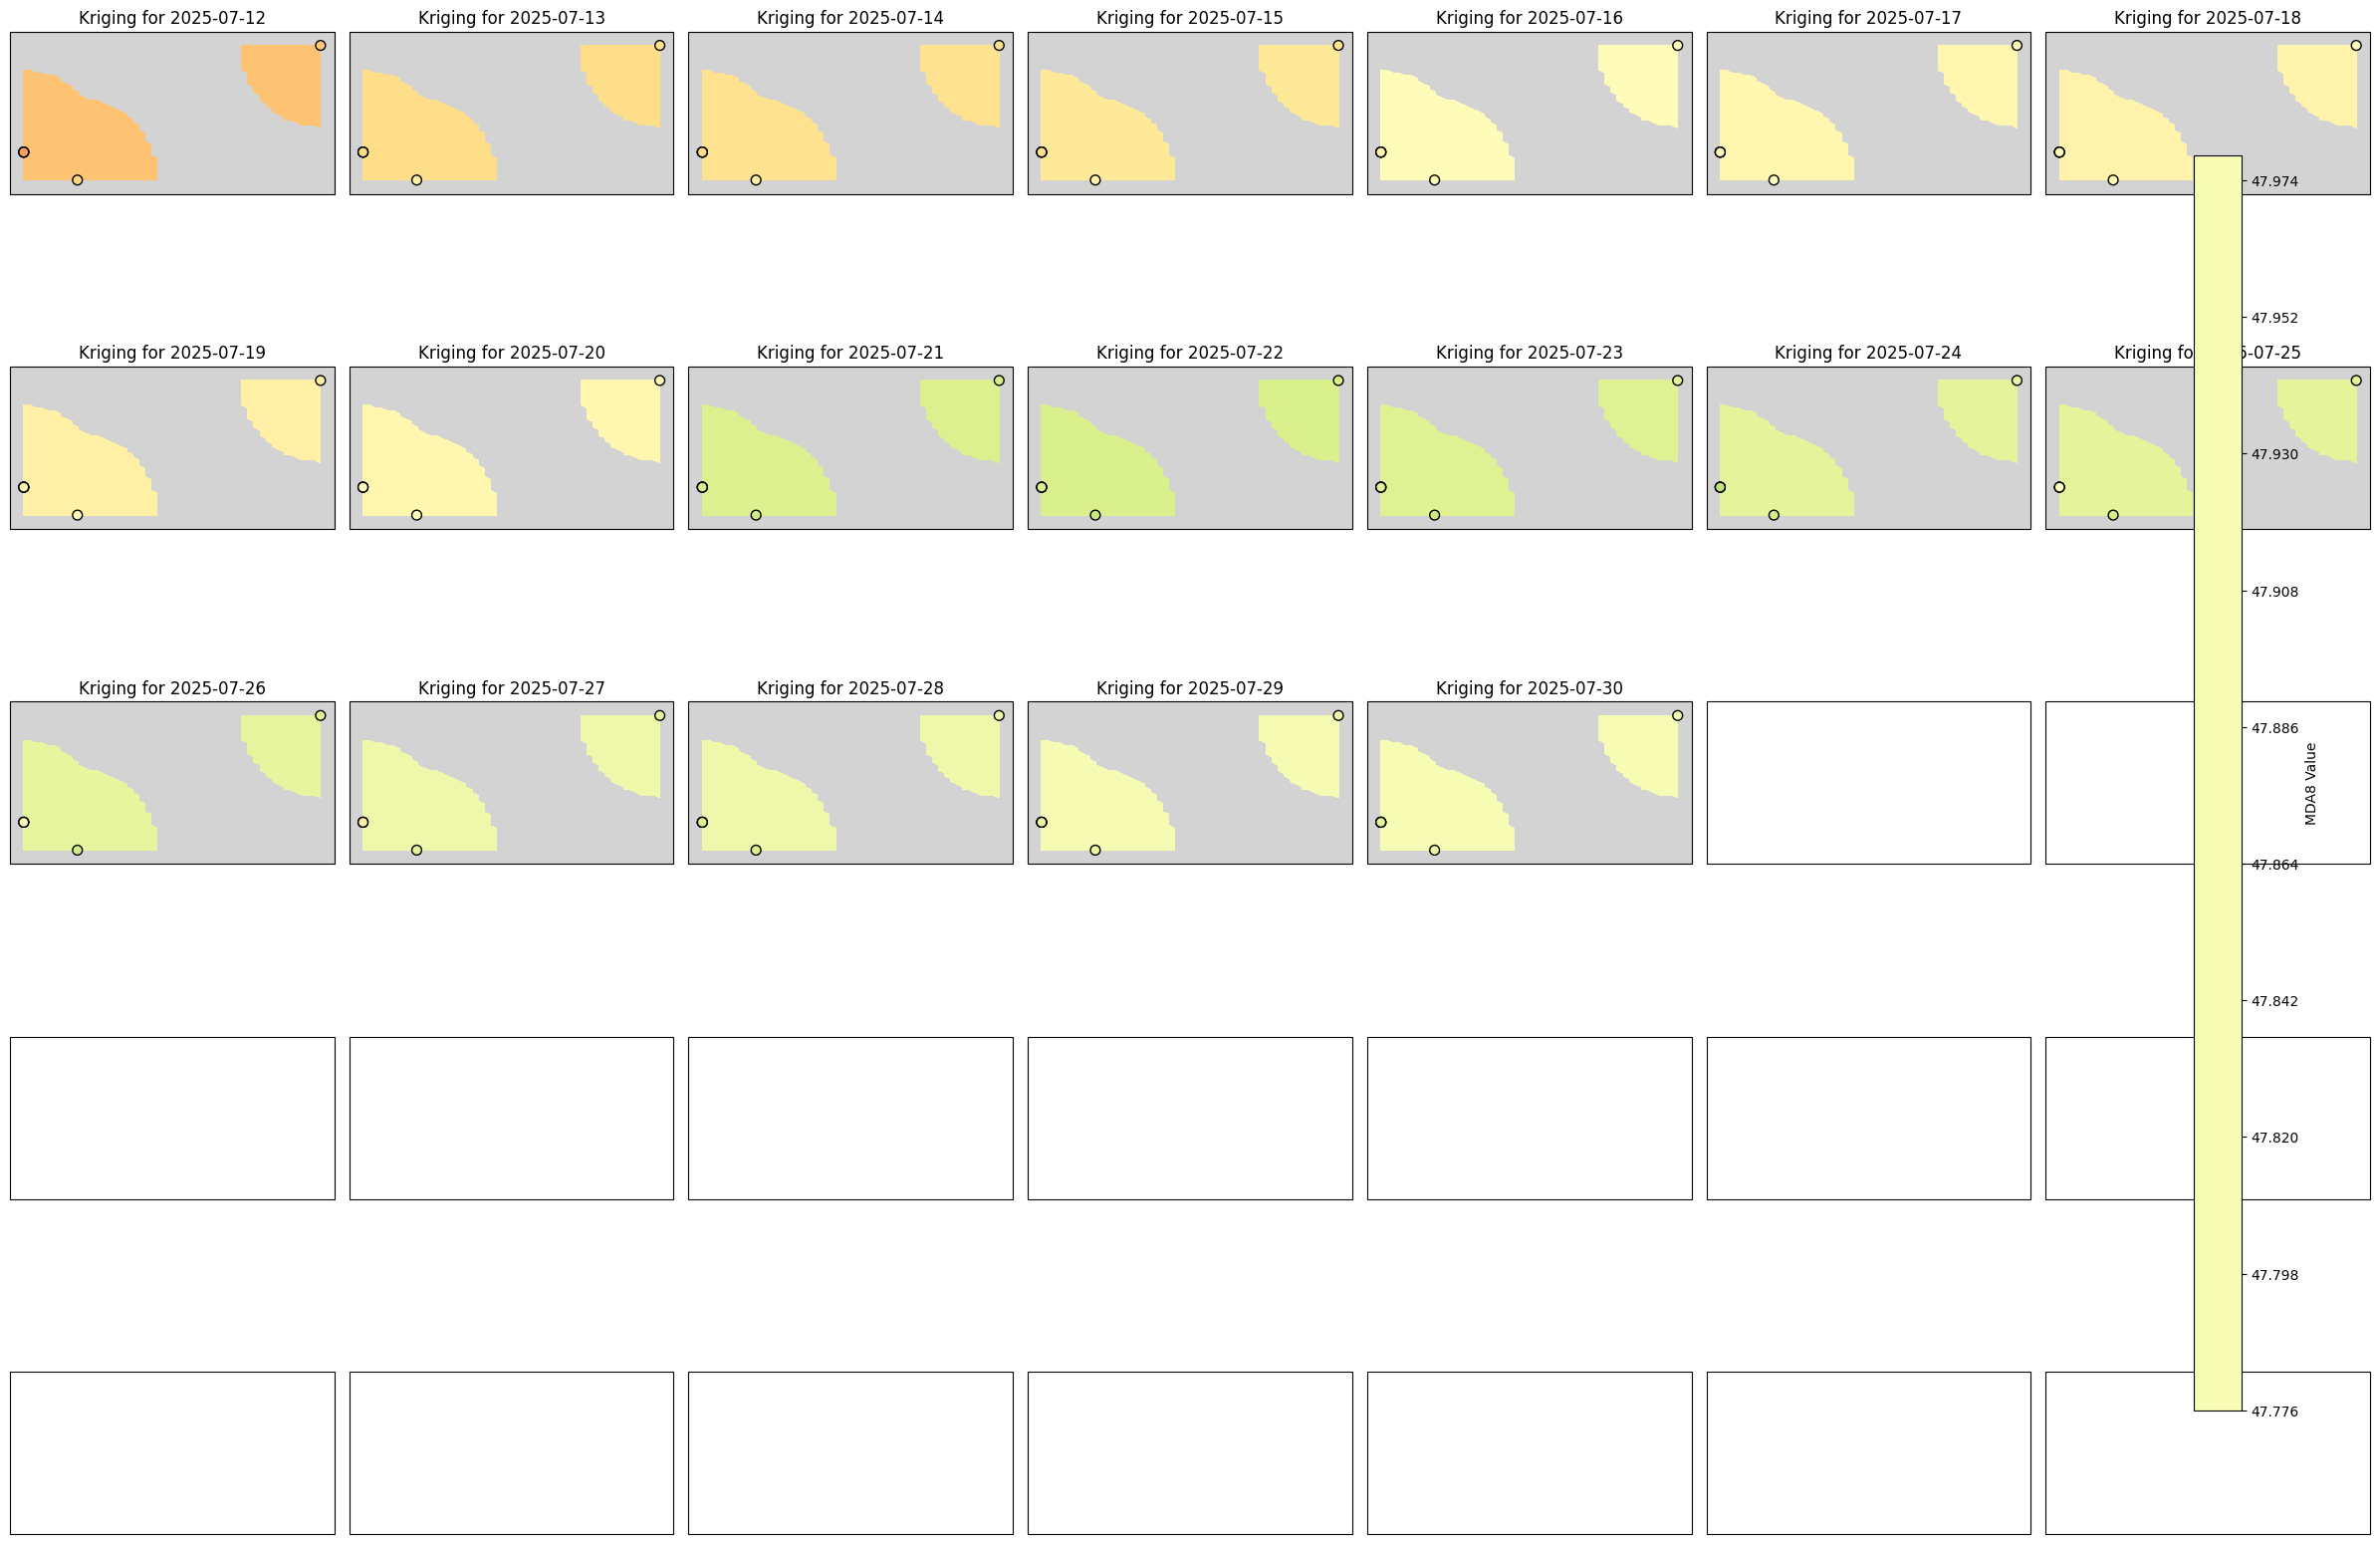

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from pykrige.ok import OrdinaryKriging
from scipy.spatial import cKDTree

coords_dfvoz = pd.read_csv(r"../reference_files/2025rawdata/deployment_locations.csv")
coords_dfref = pd.read_csv(r"../reference_files/FEMCoordinatesozone.csv")
coords_df = pd.concat([coords_dfref, coords_dfvoz])
# Create a dictionary: {name: (lat, lon)}
coords_dict = {row["name"]: (row["lat"], row["lon"]) for _, row in coords_df.iterrows()}
lat_dict = dict(zip(coords_df["name"], coords_df["lat"]))
lon_dict = dict(zip(coords_df["name"], coords_df["lon"]))

# Get unique days in July
days_in_july = pd.date_range(start='2025-07-12', end='2025-07-30', freq='D')

# Create a figure with subplots (5 rows, 7 columns for the 30 days of July)
fig, axs = plt.subplots(5, 7, figsize=(24, 18), subplot_kw={'projection': ccrs.PlateCarree()})
axs = axs.flatten()  # Flatten the 2D array of axes for easier indexing

# Define the radius of influence
radius_of_influence = 0.3  # Adjust as 

# Loop through each day in July and create a kriging plot for each
for i, day in enumerate(days_in_july):

    # --- Filter the vozdata for this day and drop NaN MDA8 values ---
    filtered = vozdata[vozdata["date_time"] == day].dropna(subset=["MDA8"])
    
    if filtered.empty:
        axs[i].set_title(f"{day.date()}: No Data")
        axs[i].axis("off")
        continue

    # --- Get the lat/lon for the filtered locations from coords_dict ---
    lats = [coords_dict[loc][0] for loc in filtered["location"]]
    lons = [coords_dict[loc][1] for loc in filtered["location"]]
    # --- Get ozone values ---
    values = filtered["MDA8"].values

    # --- Mask any remaining NaNs (just in case) ---
    mask = ~np.isnan(values)
    values_clean = values[mask]
    lats_clean = np.array(lats)[mask]
    lons_clean = np.array(lons)[mask]

    # Prepare grid for kriging
    grid_lon = np.linspace(lons_clean.min(), lons_clean.max(), 50)
    grid_lat = np.linspace(lats_clean.min(), lats_clean.max(), 50)
    grid_lon, grid_lat = np.meshgrid(grid_lon, grid_lat)

    # --- Ordinary Kriging ---
    OK = OrdinaryKriging(
        lons_clean,
        lats_clean,
        values_clean,
        variogram_model='linear',
        verbose=False,
        enable_plotting=False
    )

    # --- Build grid, execute kriging, plot contours and scatter points ---
    # (same as your old loop)


    z, ss = OK.execute("grid", grid_lon[0], grid_lat[:, 0])

    # Compute distance mask
    grid_points = np.vstack([grid_lon.ravel(), grid_lat.ravel()]).T
    data_points = np.vstack([lons_clean, lats_clean]).T
    tree = cKDTree(data_points)
    distances, _ = tree.query(grid_points)
    distance_mask = distances.reshape(grid_lon.shape)

    z = np.ma.masked_where(distance_mask > radius_of_influence, z)

    ax = axs[i]
    ax.coastlines(resolution="10m")
    ax.add_feature(cfeature.BORDERS)
    ax.add_feature(cfeature.LAND, facecolor="lightgray")
    ax.add_feature(cfeature.OCEAN, facecolor="lightblue")

    contour = ax.contourf(
        grid_lon, grid_lat, z,
        levels=100,
        cmap="RdYlGn_r",
        vmin=0, vmax=100,
        transform=ccrs.PlateCarree()
    )

    ax.scatter(
        lons_clean, lats_clean,
        c=values_clean,
        s=50, edgecolor="k",
        cmap="RdYlGn_r",
        vmin=0, vmax=100,
        transform=ccrs.PlateCarree()
    )

    ax.set_extent([
        lons_clean.min() - 0.05,
        lons_clean.max() + 0.05,
        lats_clean.min() - 0.05,
        lats_clean.max() + 0.05,
    ])

    ax.set_title(f"Kriging for {day.date()}")


# Adjust layout and add a colorbar for the entire figure
fig.tight_layout()
cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])  # Colorbar position [left, bottom, width, height]
fig.colorbar(contour, cax=cbar_ax, label='MDA8 Value')


In [2]:
file_path = r"../reference_files/2025OzoneDataCalibrated/AllMDA8Ref.csv"  # Replace with your file path
refdata = pd.read_csv(file_path, parse_dates=["date_time"])

refdata = refdata.melt(
    id_vars="date_time",
    var_name="location",
    value_name="MDA8"
)

refdata.to_csv("../reference_files/2025OzoneDataCalibrated/MDA8LongRef.csv")


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from pykrige.ok import OrdinaryKriging
from scipy.spatial import cKDTree
import cartopy.io.shapereader as shpreader
import matplotlib.lines as mlines
from pathlib import Path

# -------------------------------------------------
# Load coordinate timeline
# -------------------------------------------------
coords_timeline = pd.read_csv('../reference_files/2025rawdata/deployment_locations.csv')
coords_timeline['timestamp'] = pd.to_datetime(coords_timeline['timestamp'])
coords_timeline = coords_timeline.sort_values(['name', 'timestamp'])

coords_dfref = pd.read_csv(r"../reference_files/FEMCoordinatesozone.csv")

# -------------------------------------------------
# Define date range to loop through
# -------------------------------------------------
start_date = pd.Timestamp("2025-10-25")
end_date = pd.Timestamp("2025-11-05")
date_range = pd.date_range(start=start_date, end=end_date, freq='D')

# Ensure consistent datetime
vozdata['date'] = pd.to_datetime(vozdata['date_time'])
refdata['date'] = pd.to_datetime(refdata['date_time'])

# Drop missing values
vozdata = vozdata.dropna(subset=["MDA8"])
refdata = refdata.dropna(subset=["MDA8"])

radius_of_influence = 0.3

# Create output directory if it doesn't exist
output_dir = Path("../../PlotsForRubenNov25/KrigingMaps")
output_dir.mkdir(parents=True, exist_ok=True)

# Add this helper function near the top with your other functions
def spread_overlapping_points(lons, lats, threshold=0.01, offset=0.05):
    """
    Spread out points that are within a threshold distance of each other.
    
    Parameters:
    - lons, lats: arrays of coordinates
    - threshold: distance threshold in degrees (0.01 ≈ 1.1 km)
    - offset: distance to offset overlapping points
    
    Returns:
    - adjusted lons and lats arrays
    """
    from scipy.spatial.distance import pdist, squareform
    
    coords = np.column_stack([lons, lats])
    adjusted_lons = lons.copy()
    adjusted_lats = lats.copy()
    
    # Calculate pairwise distances between all points
    distances = squareform(pdist(coords))
    
    # Find groups of close points
    already_grouped = set()
    
    for i in range(len(coords)):
        if i in already_grouped:
            continue
            
        # Find all points within threshold distance of point i
        close_points = np.where(distances[i] <= threshold)[0]
        
        if len(close_points) > 1:
            # Mark these points as grouped
            already_grouped.update(close_points)
            
            # Calculate centroid of the group
            centroid_lon = np.mean(lons[close_points])
            centroid_lat = np.mean(lats[close_points])
            
            # Spread them in a circle around the centroid
            angles = np.linspace(0, 2 * np.pi, len(close_points), endpoint=False)
            for j, idx in enumerate(close_points):
                adjusted_lons[idx] = centroid_lon + offset * np.cos(angles[j])
                adjusted_lats[idx] = centroid_lat + offset * np.sin(angles[j])
    
    return adjusted_lons, adjusted_lats
# -------------------------------------------------
# Helper: extract lat/lon/value from coords_dict
# -------------------------------------------------
def get_coords(df, coords_dict):
    df = df[df["location"].isin(coords_dict.keys())]

    lats = df["location"].apply(lambda x: coords_dict[x][0]).values
    lons = df["location"].apply(lambda x: coords_dict[x][1]).values
    vals = df["MDA8"].values

    mask = ~np.isnan(vals)
    return lats[mask], lons[mask], vals[mask]


# -------------------------------------------------
# Function to get coordinates for a specific date
# -------------------------------------------------
def get_coords_for_date(date, coords_timeline):
    """
    Returns a dictionary mapping monitor names to (lat, lon) for a given date.
    For VOZ monitors with time-varying locations.
    """
    coords_dict = {}
    
    for name in coords_timeline['name'].unique():
        # Skip Coalinguita after 10/23/2025
        if name == 'Coalinguita' and date >= pd.Timestamp('2025-10-24'):
            continue
            
        # Get all entries for this monitor
        monitor_coords = coords_timeline[coords_timeline['name'] == name]
        
        # Find the most recent coordinate entry on or before the given date
        valid_coords = monitor_coords[monitor_coords['timestamp'] <= date]
        
        if len(valid_coords) > 0:
            # Get the most recent entry
            latest = valid_coords.iloc[-1]
            coords_dict[name] = (latest['lat'], latest['lon'])
    
    return coords_dict

def get_static_coords(coords_df):
    """
    Returns a dictionary mapping monitor names to (lat, lon) for static monitors.
    For reference monitors that don't move.
    """
    coords_dict = {}
    for _, row in coords_df.iterrows():
        coords_dict[row['name']] = (row['lat'], row['lon'])
    return coords_dict

# Create static reference coordinates dictionary once
ref_coords_dict = get_static_coords(coords_dfref)

# -------------------------------------------------
# Loop through each day
# -------------------------------------------------
for day_to_plot in date_range:
    print(f"\nProcessing {day_to_plot.date()}...")
    
    # Get coordinates valid for this specific date (VOZ monitors)
    voz_coords_dict = get_coords_for_date(day_to_plot, coords_timeline)  # ← FIXED: was coords_dfvoz
    
    # Filter 1-day data
    voz_day = vozdata[vozdata["date"] == day_to_plot]
    ref_day = refdata[refdata["date"] == day_to_plot]

    # Get coordinate arrays
    lats_v, lons_v, vals_v = get_coords(voz_day, voz_coords_dict)
    lats_r, lons_r, vals_r = get_coords(ref_day, ref_coords_dict)
    
    print(f"VOZ monitors: {len(vals_v)}, REF monitors: {len(vals_r)}")

    # Combine
    lats = np.hstack([lats_v, lats_r])
    lons = np.hstack([lons_v, lons_r])
    vals = np.hstack([vals_v, vals_r])
    
    if len(vals) == 0:
        print(f"No data available for {day_to_plot.date()}, skipping...")
        continue
        
    # -------------------------------------------------
    # Build grid
    # -------------------------------------------------
    grid_lon = np.linspace(lons.min() - radius_of_influence, lons.max() + radius_of_influence, 50)
    grid_lat = np.linspace(lats.min() - radius_of_influence, lats.max() + radius_of_influence, 50)
    grid_lon, grid_lat = np.meshgrid(grid_lon, grid_lat)

    # Kriging
    try:
        OK = OrdinaryKriging(
            lons, lats, vals,
            variogram_model="linear",
            verbose=False,
            enable_plotting=False
        )

        z, ss = OK.execute("grid", grid_lon[0], grid_lat[:, 0])
    except Exception as e:
        print(f"Kriging failed for {day_to_plot.date()}: {e}, skipping...")
        continue

    # Distance mask
    grid_points = np.vstack([grid_lon.ravel(), grid_lat.ravel()]).T
    data_points = np.vstack([lons, lats]).T
    tree = cKDTree(data_points)
    distances, _ = tree.query(grid_points)
    distance_mask = distances.reshape(grid_lon.shape)

    z = np.ma.masked_where(distance_mask > radius_of_influence, z)

    # Check valid variation
    zz = z.compressed()
    if len(zz) == 0 or zz.min() == zz.max():
        print(f"Not enough variation to contour for {day_to_plot.date()}, skipping...")
        continue

    # -------------------------------------------------
    # Plot single map
    # -------------------------------------------------
    fig = plt.figure(figsize=(10, 8))
    ax = plt.axes(projection=ccrs.PlateCarree())

    # Base map features
    ax.coastlines(resolution='10m')
    ax.add_feature(cfeature.BORDERS)
    ax.add_feature(cfeature.LAND, facecolor='lightgray')
    ax.add_feature(cfeature.OCEAN, facecolor='lightblue')
    ax.add_feature(cfeature.LAKES, facecolor='lightblue')
    ax.add_feature(cfeature.RIVERS)

    # Fixed contour levels
    levels = np.linspace(0, 100, 101)

    contour = ax.contourf(
        grid_lon, grid_lat, z,
        levels=levels,
        cmap="RdYlGn_r",
        vmin=0, vmax=100,
        transform=ccrs.PlateCarree()
    )

    cbar = plt.colorbar(contour, ax=ax)
    cbar.set_ticks(np.arange(0, 101, 10))
    cbar.set_label("MDA8 Ozone [ppb]", fontsize=12)
    
    # Scatter points
    if len(vals_v) > 0:
        # Spread out overlapping VOZ monitors
        lons_v_spread, lats_v_spread = spread_overlapping_points(lons_v, lats_v)
        
        ax.scatter(
            lons_v_spread, lats_v_spread, c=vals_v,
            s=80, edgecolor='k', cmap="RdYlGn_r",
            vmin=0, vmax=100, marker='o',
            transform=ccrs.PlateCarree(),
            label="VOZ"
        )

    if len(vals_r) > 0:
        ax.scatter(
            lons_r, lats_r, c=vals_r,
            s=80, edgecolor='k', cmap="RdYlGn_r",
            vmin=0, vmax=100, marker='^',
            transform=ccrs.PlateCarree(),
            label="REF"
        )

    # Zoomed-out map extent
    zoom_out_deg = 1.5

    ax.set_extent([
        lons.min() - zoom_out_deg,
        lons.max() + zoom_out_deg,
        lats.min() - zoom_out_deg,
        lats.max() + zoom_out_deg
    ], crs=ccrs.PlateCarree())

    ax.add_feature(cfeature.NaturalEarthFeature('cultural', 'roads', '10m', 
                                                    edgecolor='gray', facecolor='none', linewidth=1), label='Highways')

    shpfilename = shpreader.natural_earth(resolution='10m', category='cultural', name='populated_places')
    reader = shpreader.Reader(shpfilename)

    for city in reader.records():
        city_name = city.attributes['NAME']
        city_lon, city_lat = city.geometry.x, city.geometry.y

        if (lons.min() - 1.5 <= city_lon <= lons.max() + 1.5 and
            lats.min() - 1.5 <= city_lat <= lats.max() + 1.5):

            ax.plot(city_lon, city_lat, 'kx', markersize=5, transform=ccrs.PlateCarree())
            ax.text(city_lon + 0.05, city_lat - 0.025, city_name, fontsize=9, transform=ccrs.PlateCarree())

    # Update custom_cities to use current coordinates for this date
    custom_cities = {
        "Coalinga":    (36.13999659771615, -120.35938694925237),
        "Avenal": (36.004190729937605, -120.13038009344021),
        "McFarland":   (35.67865733239519, -119.22690100812619),
        "Lost Hills": (35.61722852439872, -119.69308777332819),
        "Cutler Orosi": (36.54806396891425, -119.29109666003598),
        "Terra Bella": (35.962716703182274, -119.04405260202688)
    }

    for name, (lat, lon) in custom_cities.items():
        # Add city name
        ax.text(
            lon + 0.07, lat - 0.025,
            name,
            fontsize=9,
            color='black',
            transform=ccrs.PlateCarree(),
            zorder=21,
        )

    ax.set_title(f"Kriging Interpolation\n{day_to_plot.date()}", fontsize=14)

    # Proxy artists
    highway_proxy = mlines.Line2D([], [], color='gray', linewidth=1, label='Highways')
    city_proxy = mlines.Line2D([], [], color='black', marker='x', linestyle='None',
                               markersize=7, label='Cities')
    
    plt.legend(handles=[
        highway_proxy, city_proxy
    ] + ax.get_legend_handles_labels()[0],
               loc='upper right')
    
    # Save with date in filename
    output_filename = output_dir / f"KrigingMap_{day_to_plot.strftime('%Y-%m-%d')}.jpg"
    plt.savefig(output_filename, format='jpg', dpi=300, bbox_inches='tight')
    plt.close(fig)
    
    print(f"Saved: {output_filename}")

print("\nAll maps generated!")


Processing 2025-10-25...
VOZ monitors: 4, REF monitors: 13


C:\Users\tlc72\AppData\Local\Temp\ipykernel_51644\630676925.py:315: UserWarning: Legend does not support handles for FeatureArtist instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ] + ax.get_legend_handles_labels()[0],


Saved: ..\..\PlotsForRubenNov25\KrigingMaps\KrigingMap_2025-10-25.jpg

Processing 2025-10-26...
VOZ monitors: 4, REF monitors: 13


C:\Users\tlc72\AppData\Local\Temp\ipykernel_51644\630676925.py:315: UserWarning: Legend does not support handles for FeatureArtist instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ] + ax.get_legend_handles_labels()[0],


Saved: ..\..\PlotsForRubenNov25\KrigingMaps\KrigingMap_2025-10-26.jpg

Processing 2025-10-27...
VOZ monitors: 3, REF monitors: 13


...

Saved: ..\..\PlotsForRubenNov25\KrigingMaps\KrigingMap_2025-11-03.jpg

Processing 2025-11-04...
VOZ monitors: 3, REF monitors: 13


C:\Users\tlc72\AppData\Local\Temp\ipykernel_51644\630676925.py:315: UserWarning: Legend does not support handles for FeatureArtist instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ] + ax.get_legend_handles_labels()[0],


Saved: ..\..\PlotsForRubenNov25\KrigingMaps\KrigingMap_2025-11-04.jpg

Processing 2025-11-05...
VOZ monitors: 2, REF monitors: 13


C:\Users\tlc72\AppData\Local\Temp\ipykernel_51644\630676925.py:315: UserWarning: Legend does not support handles for FeatureArtist instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ] + ax.get_legend_handles_labels()[0],


Saved: ..\..\PlotsForRubenNov25\KrigingMaps\KrigingMap_2025-11-05.jpg

All maps generated!
